In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

#Load data set
df = pd.read_csv("USArrests.csv")

# Look at the first few rows
print("First 5 rows of the dataset:")
print(df.head())

#Check data types
print("Data information")
print(df.info())

# Check for missing values
print("\nMissing values in the dataset:")
print(df.isnull().sum())

# Get basic statistics
print("\nBasic statistics:")
print(df.describe())

First 5 rows of the dataset:
   Murder  Assault  UrbanPop  Rape       State
0    13.2      236        58  21.2     Alabama
1    10.0      263        48  44.5      Alaska
2     8.1      294        80  31.0     Arizona
3     8.8      190        50  19.5    Arkansas
4     9.0      276        91  40.6  California
Data information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None

Missing values in the dataset:
Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

Basic statistics:
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000

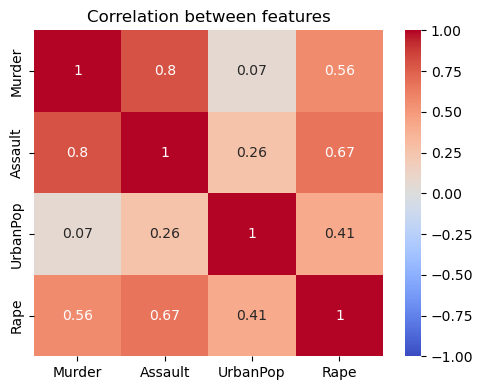

In [3]:
#checking whether any of them are redundant enough to drop before modelling, rather than running a formal selection algorithm.
features = ["Murder", "Assault", "UrbanPop", "Rape"]
corr = df[features].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between features")
plt.tight_layout()
plt.show()

Murder, Assault and Rape are all positively correlated with each other (they move together — violent crime tends to be broadly high or broadly low in a state), while `UrbanPop` is nearly uncorrelated with `Murder` (r = 0.07). None of the correlations are high enough (>0.9) to call a feature purely redundant, so **all 4 features are kept**. Instead of dropping columns by hand, PCA is used next to compress the redundancy that does exist into a smaller number of components.

In [4]:
#Standardiize features
X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

In [5]:
#Dimensionality reduction with PCA
pca = PCA()

# Fit PCA model to data
pca.fit(X_scaled)

# Transform the data to the new PC space
X_pca = pca.transform(X_scaled)

# Create a DataFrame with the principal components
pca_df = pd.DataFrame(
    data=X_pca,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
)

# Look at the transformed data
print("First 5 rows of PCA-transformed data:")
print(pca_df.head())

First 5 rows of PCA-transformed data:
        PC1       PC2       PC3       PC4
0  0.985566 -1.133392 -0.444269 -0.156267
1  1.950138 -1.073213  2.040003  0.438583
2  1.763164  0.745957  0.054781  0.834653
3 -0.141420 -1.119797  0.114574  0.182811
4  2.523980  1.542934  0.598557  0.341996


Variance explained by each principal component:
  Principal Component  Eigenvalue  Variance Explained (%)  \
0                 PC1    2.530859               62.006039   
1                 PC2    1.009964               24.744129   
2                 PC3    0.363840                8.914080   
3                 PC4    0.176969                4.335752   

   Cumulative Variance Explained (%)  
0                          62.006039  
1                          86.750168  
2                          95.664248  
3                         100.000000  


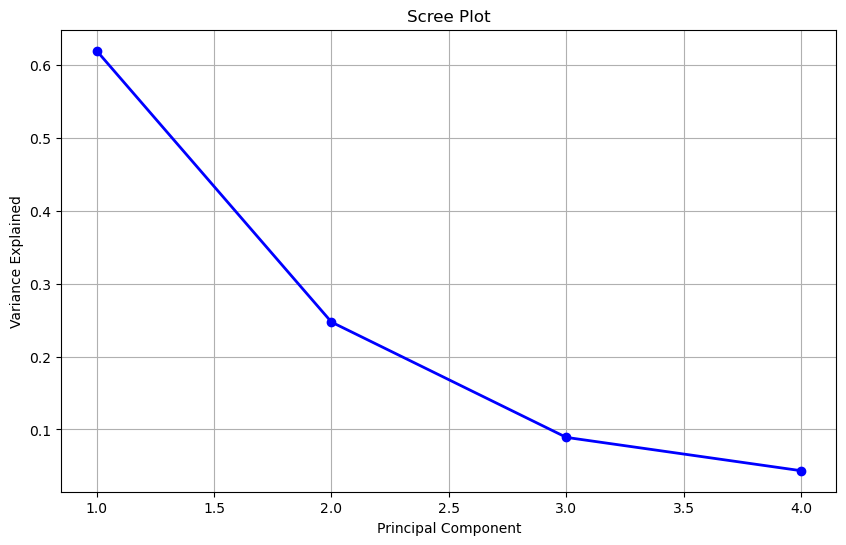

In [6]:
## Examine explained variance
explained_variance = pca.explained_variance_
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Create a dataframe for better display
variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Eigenvalue': explained_variance,
    'Variance Explained (%)': explained_variance_ratio * 100,
    'Cumulative Variance Explained (%)': cumulative_variance_ratio * 100
})

print("Variance explained by each principal component:")
print(variance_df)

# Create scree plot to find optimal number of PCs
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()


The first two components already explain about **87%** of the total variance, so the data is reduced to 2 dimensions (`PC1`, `PC2`) for clustering and visualization.

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = X_pca[:, 0], X_pca[:, 1]

loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=features)
loadings.round(3)

,PC1,PC2
Murder,0.536,-0.418
Assault,0.583,-0.188
UrbanPop,0.278,0.873
Rape,0.543,0.167


**Reading the loadings:** `PC1` loads positively and fairly evenly on `Murder`, `Assault` and `Rape` — it's essentially an *overall violent crime* axis. `PC2` loads heavily and positively on `UrbanPop` (and mildly negatively on `Murder`) — it separates states by how urban they are, roughly independent of crime level.

C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

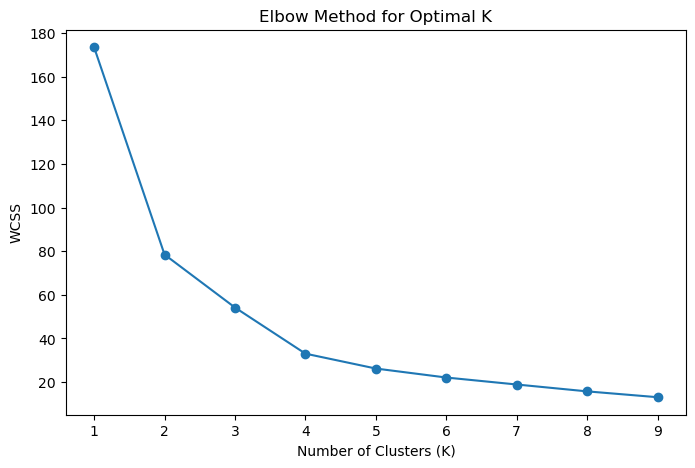

In [8]:
# Determine the optimal number of clusters using the Elbow Method
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 10), wcss, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()


**k=4** is chosen as a reasonable balance between fit quality and having clusters detailed enough to be actionable.

In [9]:
# Apply K-Means with the optimal K (from Elbow Method)
k_final = 4
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_pca)
df["KMeans_Cluster"].value_counts().sort_index()

# Validate clustering with Silhouette Score
silhouette_avg = silhouette_score(X_pca, kmeans.labels_)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.4439777353995337


C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

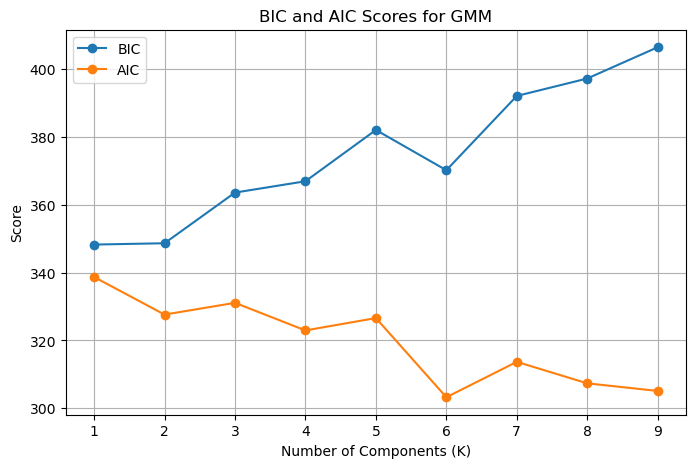

In [10]:
#Gaussian Mixture Model clustering
#Using BIC/AIC (lower = better) to pick the number of components, and allowing soft, elliptical (not just spherical) clusters.
bic_scores = []
aic_scores = []
k_values = range(1, 10)

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

# Plot BIC and AIC to find optimal K
plt.figure(figsize=(8, 5))
plt.plot(k_values, bic_scores, marker='o', linestyle='-', label='BIC')
plt.plot(k_values, aic_scores, marker='o', linestyle='-', label='AIC')
plt.xlabel('Number of Components (K)')
plt.ylabel('Score')
plt.legend()
plt.title('BIC and AIC Scores for GMM')
plt.grid(True)
plt.show()

BIC is actually lowest (best) at n=2. AIC is noisier and doesn't point to a clean choice. Given that trade-off, **n=4** is used to match K-Means so the two methods can be compared directly on the same number of groups, while noting that a stricter model-selection criterion (BIC) would argue for fewer, broader clusters.

In [11]:
n_final = 4
gmm = GaussianMixture(n_components=n_final, covariance_type="full", random_state=42, n_init=5)
df["GMM_Cluster"] = gmm.fit_predict(X_pca)
df["GMM_Cluster"].value_counts().sort_index()

C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\envs\ml-env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is k

GMM_Cluster
0     5
1    19
2    11
3    15
Name: count, dtype: int64

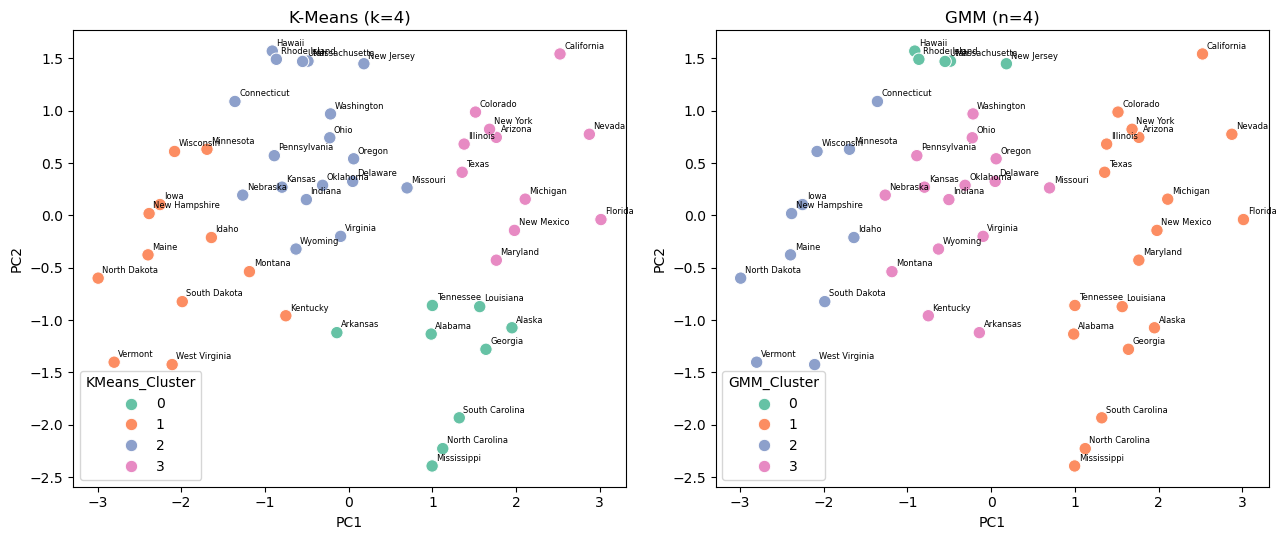

In [12]:
#Comparing the two

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
for ax, col, title in zip(axes, ["KMeans_Cluster", "GMM_Cluster"], ["K-Means (k=4)", "GMM (n=4)"]):
    sns.scatterplot(data=df, x="PC1", y="PC2", hue=col, palette="Set2", s=80, ax=ax, legend="full")
    for _, row in df.iterrows():
        ax.text(row["PC1"]+0.05, row["PC2"]+0.05, row["State"], fontsize=6)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [13]:
sil_km4 = silhouette_score(X_pca, df["KMeans_Cluster"])
sil_gmm4 = silhouette_score(X_pca, df["GMM_Cluster"])

print(f"Silhouette -- KMeans(k=4): {sil_km4:.3f}")
print(f"Silhouette -- GMM(n=4):    {sil_gmm4:.3f}")

Silhouette -- KMeans(k=4): 0.444
Silhouette -- GMM(n=4):    0.344


K-Means gets the higher silhouette score here, which makes sense — silhouette rewards compact, well-separated (roughly spherical) clusters, and K-Means is built to find exactly that. GMM allows elliptical, differently-shaped clusters and assigns soft probabilities, so it can pick up a different (not wrong) structure. For this dataset, k-means is better because it gives a rigid, locked-in, well-defined class as opposed to GMM which works with probabilities.

In [14]:
profile = df.groupby("KMeans_Cluster")[features].mean().round(1)
profile["n_states"] = df["KMeans_Cluster"].value_counts().sort_index()
for c in sorted(df["KMeans_Cluster"].unique()):
    states = ", ".join(df[df["KMeans_Cluster"] == c]["State"])
    print(f"Cluster {c}: {states}\n")

Cluster 0: Alabama, Alaska, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee

Cluster 1: Idaho, Iowa, Kentucky, Maine, Minnesota, Montana, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Cluster 2: Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Missouri, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

Cluster 3: Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas



**Cluster read-out:**
- **High violent crime, less urban** (e.g. Alabama, Georgia, Mississippi, South Carolina, Tennessee) — Southern states with elevated Murder/Assault but comparatively lower UrbanPop.
- **Low crime, rural** (e.g. Maine, Iowa, Vermont, North/South Dakota) — consistently the lowest arrest rates across all three crime types.
- **Moderate crime, urban** (e.g. Ohio, Pennsylvania, Massachusetts, Connecticut) — mid-range crime rates paired with high UrbanPop.
- **High crime, urban** (e.g. California, Florida, Nevada, New York, Michigan) — the highest Assault and Rape rates, combined with high UrbanPop — large, urbanized states.

This is useful for the research firm: it shows crime patterns don't split cleanly along a single "urban vs rural" line — urbanization and violent-crime intensity are two fairly independent axes (matching what PC1 vs PC2 showed), so policy responses probably need to be tailored differently for, say, high-crime/rural states vs high-crime/urban states rather than treated as one group.

## 9. Conclusion

- All 4 features were kept; PCA was used to reduce redundancy, capturing ~87% of variance in 2 components.
- PC1 represents overall violent crime level; PC2 represents urbanization.
- K-Means (k=4) produced tighter, better-separated clusters (silhouette 0.44) than GMM (n=4, silhouette 0.34) on this data, likely because the underlying groups are fairly compact and roughly similar in spread.
- Four regional-style groupings emerged that combine crime intensity with urbanization level, which is more actionable for policy than a single high/low crime split.